# Cannibalization-Aware Demand Forecast

Pipeline (see [8.fluxo.md](8.fluxo.md)):

1. **TransactionAnalyzer** — co-occurrence metrics (Lift & Hypergeometric p-value) → competitor adjacency mask `G_adj`
2. **Panel de série temporal** — agregação de vendas/preços + variáveis de controle, isolado via `G_adj`
3. **Elasticidade cruzada causal** — Double Machine Learning (EconML) para estimar `\hat{\gamma}_{BA}`
4. **Forecast contrafactual** — demanda base + ajuste de canibalização `Y_final = Y_base * (1 + \sum \gamma \Delta P)`


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)


## Step 1 — TransactionAnalyzer: Máscara de SKUs Concorrentes (`G_adj`)

Mock direto das métricas de co-ocorrência (Lift & p-valor Hipergeométrico) que o `TransactionAnalyzer`
produziria a partir de um histórico de transações, para dois grupos de produtos concorrentes
(bebidas e snacks) mais um item complementar (guardanapo):

- Pares **dentro do mesmo grupo** (substitutos): `lift < 1` e p-valor baixo ⇒ evidência de **concorrência**
- Pares **entre grupos diferentes** ou envolvendo o complemento: `lift ≈ 1` ou `> 1` e p-valor alto ⇒ **sem concorrência** (complementares/neutros)

O objetivo é extrair, a partir dessas métricas, os pares de SKUs concorrentes que serão isolados no `G_adj`.


In [2]:
# Two competing product groups + a complementary item
BEVERAGES = ["cola_A", "cola_B", "cola_C"]
SNACKS = ["chips_A", "chips_B"]
COMPLEMENT = "napkin"
SKUS = BEVERAGES + SNACKS + [COMPLEMENT]

GROUP_OF = {
    **{sku: "beverage" for sku in BEVERAGES},
    **{sku: "snack" for sku in SNACKS},
    COMPLEMENT: "complement",
}


def mock_lift_pvalue(skus: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Mock lift & hypergeometric p-value matrices as TransactionAnalyzer would output them."""
    n = len(skus)
    lift = np.ones((n, n))
    pvalue = np.ones((n, n))

    for i, a in enumerate(skus):
        for j, b in enumerate(skus):
            if i >= j:
                continue

            same_competing_group = GROUP_OF[a] == GROUP_OF[b] and GROUP_OF[a] != "complement"
            involves_complement = GROUP_OF[a] == "complement" or GROUP_OF[b] == "complement"

            if same_competing_group:  # substitutes: strong negative lift, high significance
                l, p = rng.uniform(0.55, 0.85), rng.uniform(0.0005, 0.02)
            elif involves_complement:  # mild complementarity, moderate significance
                l, p = rng.uniform(1.05, 1.25), rng.uniform(0.01, 0.08)
            else:  # beverage x snack: complementary, weak/no statistical signal
                l, p = rng.uniform(0.95, 1.15), rng.uniform(0.1, 0.6)

            lift[i, j] = lift[j, i] = l
            pvalue[i, j] = pvalue[j, i] = p

    return pd.DataFrame(lift, index=skus, columns=skus), pd.DataFrame(pvalue, index=skus, columns=skus)

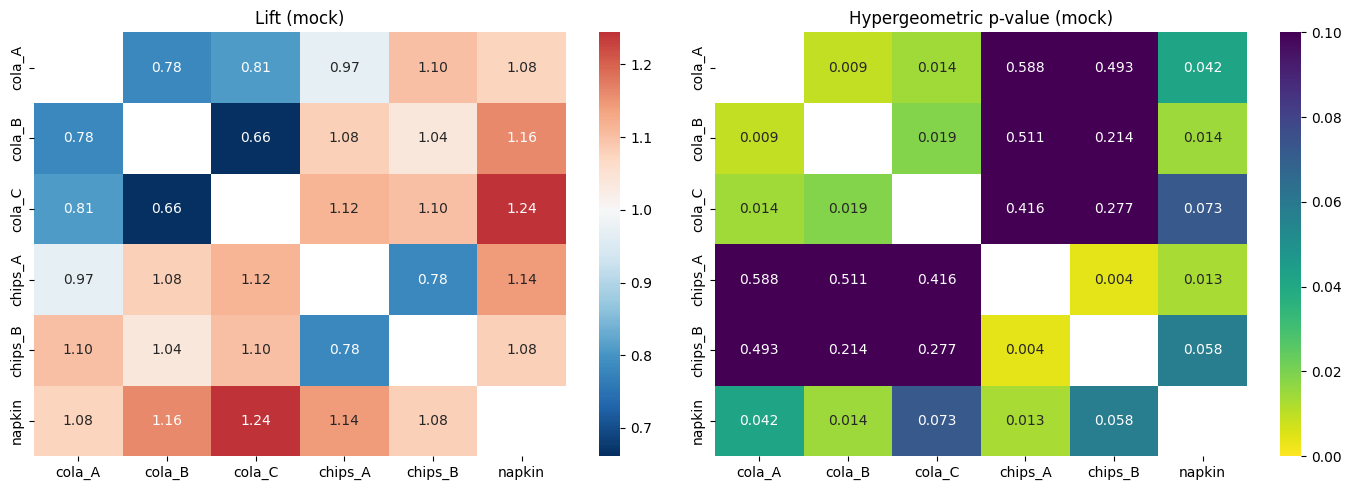

In [3]:
lift_matrix, pvalue_matrix = mock_lift_pvalue(SKUS)

np.fill_diagonal(lift_matrix.values, np.nan)
np.fill_diagonal(pvalue_matrix.values, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(lift_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=1, ax=axes[0])
axes[0].set_title("Lift (mock)")
sns.heatmap(pvalue_matrix, annot=True, fmt=".3f", cmap="viridis_r", vmin=0, vmax=0.1, ax=axes[1])
axes[1].set_title("Hypergeometric p-value (mock)")
plt.tight_layout()
plt.show()


Competitor pairs (G_adj):
      cola_A <-> cola_B      lift=0.78  p=0.0091
      cola_A <-> cola_C      lift=0.81  p=0.0141
      cola_B <-> cola_C      lift=0.66  p=0.0186
     chips_A <-> chips_B     lift=0.78  p=0.0043


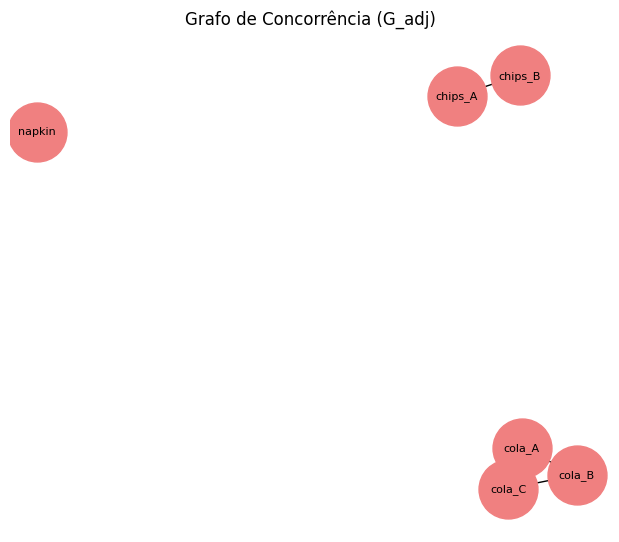

In [4]:
LIFT_THRESHOLD = 1.0
PVALUE_THRESHOLD = 0.05

# G_adj[i, j] = True <=> i and j are statistically significant substitutes (competitors)
G_adj = (lift_matrix < LIFT_THRESHOLD) & (pvalue_matrix < PVALUE_THRESHOLD)
G_adj = G_adj.fillna(False)

competitor_pairs = [
    (a, b) for a in SKUS for b in SKUS if a < b and G_adj.loc[a, b]
]
print("Competitor pairs (G_adj):")
for pair in competitor_pairs:
    print(f"  {pair[0]:>10} <-> {pair[1]:<10}  lift={lift_matrix.loc[pair]:.2f}  p={pvalue_matrix.loc[pair]:.4f}")

G = nx.Graph()
G.add_nodes_from(SKUS)
G.add_edges_from(competitor_pairs)

plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightcoral", node_size=1800, font_size=8)
plt.title("Grafo de Concorrência (G_adj)")
plt.show()


## Step 2 — Painel de Série Temporal & Tratamento Econométrico

Mock de um painel diário `(sku, date) -> (demanda, preço)` para os SKUs de bebidas (o grupo onde
vamos estimar a canibalização), enriquecido com variáveis de controle (sazonalidade de dia da
semana, feriados e um indicador de marketing). A demanda de cada SKU depende do próprio preço
(elasticidade própria negativa) e do preço dos **vizinhos em `G_adj`** (elasticidade cruzada
positiva ⇒ canibalização), além de ruído e confundidores comuns (sazonalidade/marketing afetam
preço e demanda simultaneamente — por isso precisamos de DML e não de uma regressão ingênua).

In [5]:
TARGET_GROUP = BEVERAGES  # focamos a canibalização dentro do grupo de bebidas
N_DAYS = 730

dates = pd.date_range("2023-01-01", periods=N_DAYS, freq="D")

# True (latent) elasticities used only to simulate data — unknown to the estimator
OWN_ELASTICITY = {"cola_A": -1.8, "cola_B": -1.5, "cola_C": -1.2}
CROSS_ELASTICITY_TRUE = {  # gamma_{A<-B}: % change in demand_A per % change in price_B
    ("cola_A", "cola_B"): 0.35,
    ("cola_A", "cola_C"): 0.15,
    ("cola_B", "cola_A"): 0.30,
    ("cola_B", "cola_C"): 0.20,
    ("cola_C", "cola_A"): 0.10,
    ("cola_C", "cola_B"): 0.18,
}

BASE_DEMAND = {"cola_A": 500, "cola_B": 350, "cola_C": 200}
BASE_PRICE = {"cola_A": 5.0, "cola_B": 4.5, "cola_C": 4.0}

country_holidays = set(pd.to_datetime(["2023-01-01", "2023-12-25", "2024-01-01", "2024-12-25"]))


def build_panel(skus: list[str]) -> pd.DataFrame:
    """Mock a daily (sku, date) panel with confounded prices, demand and cannibalization."""
    n = len(dates)

    # Confounders: shared across SKUs, drive both price (promo) and demand (seasonality)
    dow = dates.dayofweek.to_numpy()
    weekend = (dow >= 5).astype(float)
    is_holiday = np.array([d in country_holidays for d in dates], dtype=float)
    marketing = rng.binomial(1, 0.15, size=n).astype(float)  # marketing push, raises demand & price

    price_noise = {sku: rng.normal(0, 0.15, size=n) for sku in skus}
    promo_effect = -0.20 * marketing - 0.05 * weekend  # promos/weekends push prices down a bit

    prices = {
        sku: np.clip(BASE_PRICE[sku] * (1 + promo_effect + price_noise[sku]), 0.5 * BASE_PRICE[sku], None)
        for sku in skus
    }

    panel_rows = []
    for sku in skus:
        log_demand = np.log(BASE_DEMAND[sku])
        log_demand += OWN_ELASTICITY[sku] * np.log(prices[sku] / BASE_PRICE[sku])

        for neighbor in skus:
            if neighbor == sku:
                continue
            gamma = CROSS_ELASTICITY_TRUE.get((sku, neighbor), 0.0)
            log_demand += gamma * np.log(prices[neighbor] / BASE_PRICE[neighbor])

        log_demand += 0.25 * weekend + 0.4 * is_holiday + 0.3 * marketing  # seasonality & control vars
        log_demand += rng.normal(0, 0.08, size=n)  # idiosyncratic noise

        panel_rows.append(
            pd.DataFrame(
                {
                    "date": dates,
                    "sku": sku,
                    "price": prices[sku],
                    "demand": np.exp(log_demand),
                    "dow": dow,
                    "is_weekend": weekend,
                    "is_holiday": is_holiday,
                    "marketing": marketing,
                }
            )
        )

    return pd.concat(panel_rows, ignore_index=True)


panel = build_panel(TARGET_GROUP)

# Isolamento via G_adj: para cada SKU_B, pivotamos o preço apenas dos vizinhos concorrentes
price_wide = panel.pivot(index="date", columns="sku", values="price").add_prefix("price_")
panel = panel.merge(price_wide, on="date")
panel.head()


,date,sku,price,demand,dow,is_weekend,is_holiday,marketing,price_cola_A,price_cola_B,price_cola_C
0,2023-01-01,cola_A,5.085860,912.669847,6,1.0,1.0,0.0,5.085860,4.924998,4.235659
1,2023-01-02,cola_A,4.043706,831.464968,0,0.0,0.0,1.0,4.043706,3.110888,2.641356
2,2023-01-03,cola_A,5.411554,364.335766,1,0.0,0.0,0.0,5.411554,3.923713,3.400513
3,2023-01-04,cola_A,4.859247,512.148370,2,0.0,0.0,0.0,4.859247,4.810302,4.022083
4,2023-01-05,cola_A,5.208608,463.668867,3,0.0,0.0,0.0,5.208608,5.167273,4.103804


## Step 3 — Elasticidade Cruzada Causal via DML (DoubleML)

Para cada SKU alvo `B`, isolamos os vizinhos concorrentes `{A : G_adj[A, B] = True}` e ajustamos um
`DoubleMLPLR` (Partially Linear Regression): a demanda de `B` é a *outcome* (`y`), o preço de cada
vizinho é uma coluna de *treatment* (`d`) contínua, e as variáveis de controle (sazonalidade,
feriado, marketing, preço próprio) são `x`. O `DoubleMLPLR` residualiza `y` e cada `d` com um
modelo de ML (LightGBM, via `ml_l`/`ml_m`) por cross-fitting, removendo o viés de confundidores

comuns (ex.: marketing que sobe preço **e** demanda ao mesmo tempo). Com múltiplas colunas `d`, oDoubleML ajusta um coeficiente por vizinho, tratando os demais preços-vizinho como controles.

In [6]:
from doubleml import DoubleMLData, DoubleMLPLR
from lightgbm import LGBMRegressor

CONTROL_COLS = ["dow", "is_weekend", "is_holiday", "marketing"]


def estimate_cross_elasticities(panel: pd.DataFrame, skus: list[str], G_adj: pd.DataFrame) -> pd.DataFrame:
    """Fit one DoubleMLPLR per target SKU, one treatment column per competitor neighbor in G_adj."""
    records = []

    for target in skus:
        neighbors = [s for s in skus if s != target and G_adj.loc[target, s]]
        if not neighbors:
            continue

        df_b = panel[panel["sku"] == target].reset_index(drop=True).copy()
        df_b["y_log_demand"] = np.log(df_b["demand"])
        df_b["x_log_price_own"] = np.log(df_b[f"price_{target}"])

        # one treatment column per neighbor; DoubleML fits a coefficient for each, using the rest as controls
        treatment_cols = [f"d_log_price_{n}" for n in neighbors]
        for neighbor, col in zip(neighbors, treatment_cols):
            df_b[col] = np.log(df_b[f"price_{neighbor}"])

        dml_data = DoubleMLData(
            df_b,
            y_col="y_log_demand",
            d_cols=treatment_cols,
            x_cols=CONTROL_COLS + ["x_log_price_own"],
        )

        dml_plr = DoubleMLPLR(
            dml_data,
            ml_l=LGBMRegressor(n_estimators=100, max_depth=3, verbose=-1, random_state=0),
            ml_m=LGBMRegressor(n_estimators=100, max_depth=3, verbose=-1, random_state=0),
            n_folds=3,
        )
        dml_plr.fit()

        summary = dml_plr.summary
        for neighbor, col in zip(neighbors, treatment_cols):
            records.append(
                {
                    "target": target,
                    "neighbor": neighbor,
                    "gamma_hat": summary.loc[col, "coef"],
                    "ci_lower": summary.loc[col, "2.5 %"],
                    "ci_upper": summary.loc[col, "97.5 %"],
                }
            )

    return pd.DataFrame(records)


gamma_hat_df = estimate_cross_elasticities(panel, TARGET_GROUP, G_adj)
gamma_hat_df["gamma_true"] = gamma_hat_df.apply(
    lambda r: CROSS_ELASTICITY_TRUE.get((r["target"], r["neighbor"]), np.nan), axis=1
)
gamma_hat_df

/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/sklearn/utils/vali

,target,neighbor,gamma_hat,ci_lower,ci_upper,gamma_true
0,cola_A,cola_B,0.338380,0.296319,0.380441,0.35
1,cola_A,cola_C,0.182851,0.141365,0.224338,0.15
2,cola_B,cola_A,0.309863,0.267679,0.352047,0.30
3,cola_B,cola_C,0.146613,0.109206,0.184020,0.20
4,cola_C,cola_A,0.115435,0.071961,0.158909,0.10
5,cola_C,cola_B,0.179086,0.138676,0.219496,0.18


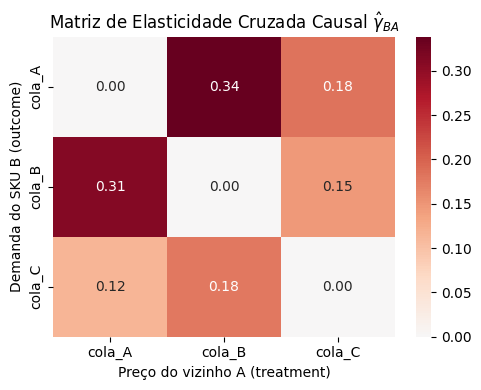

In [7]:
gamma_matrix = pd.DataFrame(0.0, index=TARGET_GROUP, columns=TARGET_GROUP)
for _, row in gamma_hat_df.iterrows():
    gamma_matrix.loc[row["target"], row["neighbor"]] = row["gamma_hat"]

plt.figure(figsize=(5, 4))
sns.heatmap(gamma_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title(r"Matriz de Elasticidade Cruzada Causal $\hat{\gamma}_{BA}$")
plt.xlabel("Preço do vizinho A (treatment)")
plt.ylabel("Demanda do SKU B (outcome)")
plt.tight_layout()
plt.show()


## Step 4 — Forecast Contrafactual com Penalidade de Canibalização

Combinamos a demanda base latente (`Y_base`, projeção *unconstrained* — aqui simplificada pela
média histórica recente, mas em produção viria do modelo de série temporal do Step 1 do
`fluxo.md`) com o ajuste de canibalização:

$$Y_{final} = Y_{base} \cdot \left(1 + \sum_{A \in \text{vizinhos}(B)} \hat{\gamma}_{BA} \cdot \Delta P_A \right)$$

`\Delta P_A` é a variação percentual de preço do concorrente `A`. O mesmo mecanismo cobre os dois
tipos de "tratamento" pedidos:

- **Tratamento de preço (contínuo)**: `\Delta P_A` = variação de preço de um concorrente.
- **Tratamento discreto (entrada/crescimento de demanda de um concorrente)**: pode ser aproximado
  como um choque equivalente de preço (ex.: lançamento/promo agressiva ⇒ `\Delta P_A` negativo
  grande) ou, de forma mais direta, substituindo `\Delta P_A` pela variação percentual de venda do
  concorrente quando o "tratamento" já é uma mudança de sortimento/demanda observada.

In [8]:
def counterfactual_forecast(
    y_base: dict[str, float],
    price_shocks: dict[str, float],
    gamma_matrix: pd.DataFrame,
) -> pd.DataFrame:
    """Apply the cannibalization penalty: Y_final = Y_base * (1 + sum gamma_BA * delta_P_A)."""
    rows = []
    for target in gamma_matrix.index:
        adjustment = sum(
            gamma_matrix.loc[target, neighbor] * price_shocks.get(neighbor, 0.0)
            for neighbor in gamma_matrix.columns
            if neighbor != target
        )
        y_final = y_base[target] * (1 + adjustment)
        rows.append(
            {"sku": target, "y_base": y_base[target], "adjustment_pct": adjustment, "y_final": y_final}
        )
    return pd.DataFrame(rows)


y_base = panel.groupby("sku")["demand"].tail(28).groupby(panel["sku"]).mean().to_dict()

# Cenário: cola_B entra em promoção agressiva (-15% de preço); demais preços inalterados
scenario_price_shocks = {"cola_B": -0.15}

forecast_df = counterfactual_forecast(y_base, scenario_price_shocks, gamma_matrix)
forecast_df


,sku,y_base,adjustment_pct,y_final
0,cola_A,650.076952,-0.050757,617.081003
1,cola_B,427.457853,0.000000,427.457853
2,cola_C,236.197605,-0.026863,229.852651


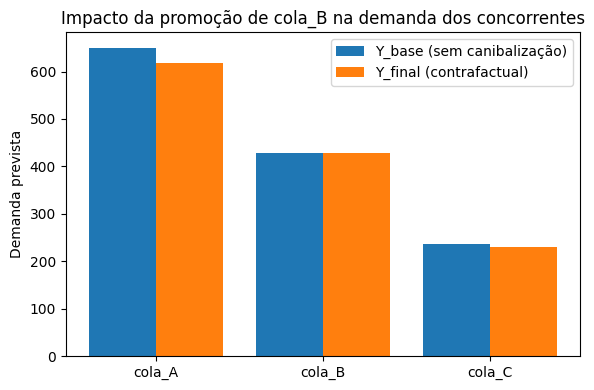

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(forecast_df))
ax.bar(x - 0.2, forecast_df["y_base"], width=0.4, label="Y_base (sem canibalização)")
ax.bar(x + 0.2, forecast_df["y_final"], width=0.4, label="Y_final (contrafactual)")
ax.set_xticks(x)
ax.set_xticklabels(forecast_df["sku"])
ax.set_ylabel("Demanda prevista")
ax.set_title("Impacto da promoção de cola_B na demanda dos concorrentes")
ax.legend()
plt.tight_layout()
plt.show()
